In [193]:
#Let's import neccessary libraries from python

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [196]:
#load CSV into enviornment

df1 = pd.read_csv(r'C:\Users\parit\Downloads\AirPassenger.csv')

In [192]:
#check on loaded data
df1.head()

,Year-Month,Pax
0,1949-Jan,112
1,1949-Feb,118
2,1949-Mar,132
3,1949-Apr,129
4,1949-May,121


In [58]:
df1.describe()

,Pax
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [59]:
#Remove index column and sent first column as index
df1 = pd.read_csv(r'C:\Users\parit\Downloads\AirPassenger.csv', parse_dates = ['Year-Month'])

C:\Users\parit\AppData\Local\Temp\ipykernel_26468\2559609291.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1 = pd.read_csv(r'C:\Users\parit\Downloads\AirPassenger.csv', parse_dates = ['Year-Month'])


In [60]:
df1 = pd.read_csv(r'C:\Users\parit\Downloads\AirPassenger.csv', parse_dates = ['Year-Month'], index_col = ['Year-Month'])

C:\Users\parit\AppData\Local\Temp\ipykernel_26468\1613511794.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1 = pd.read_csv(r'C:\Users\parit\Downloads\AirPassenger.csv', parse_dates = ['Year-Month'], index_col = ['Year-Month'])


In [61]:
df1.head()

,Pax
Year-Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


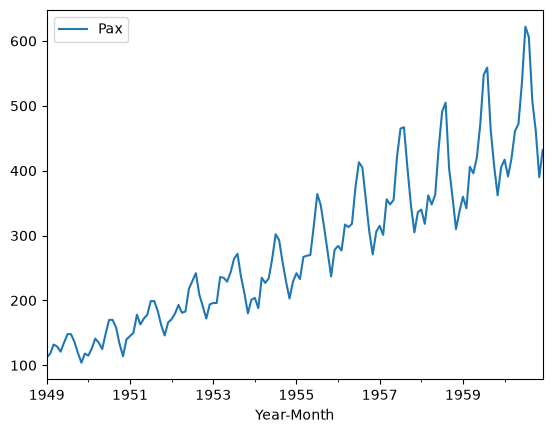

In [20]:
df1.plot()
plt.show()

In [62]:
#Control the plot
from pylab import rcParams

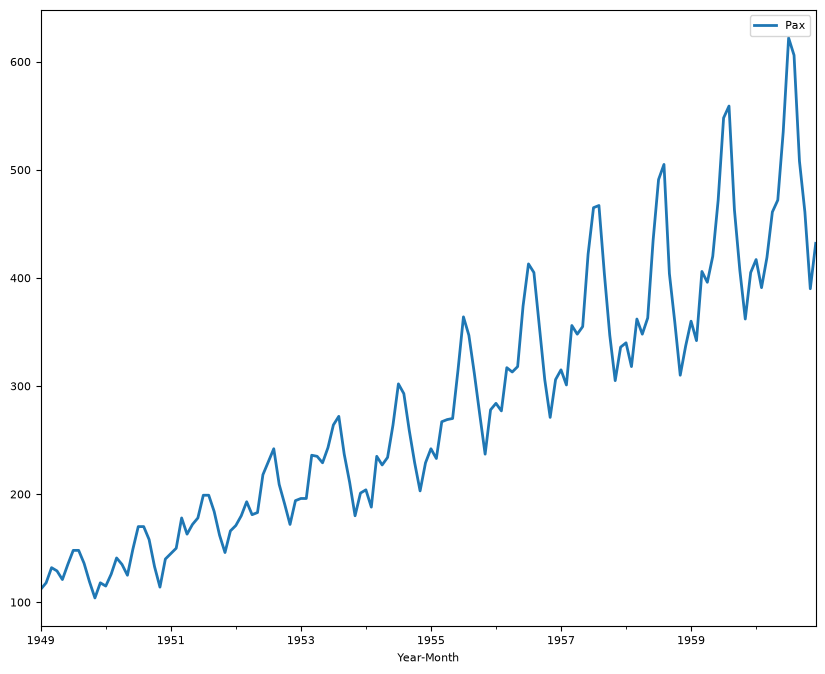

In [63]:
rcParams['figure.figsize'] = 10,8
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 8

df1.plot()
plt.show()

In [64]:
#check minimum and maximum in index for split.

print(df1.index.min())
print(df1.index.max())

df1.describe()df1.plot()

plt.title('Passenger over the years')
plt.xlabel('Year')
plt.ylabel('No. of Passenger')

plt.show()

1949-01-01 00:00:00
1960-12-01 00:00:00


,Pax
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


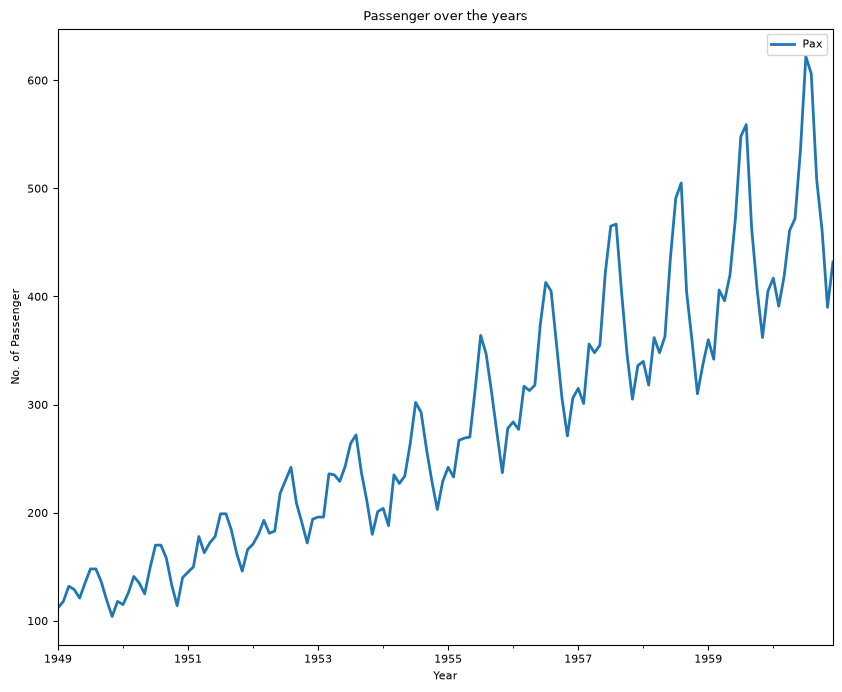

In [74]:
df1.plot()

plt.title('Passenger over the years')
plt.xlabel('Year')
plt.ylabel('No. of Passenger')


plt.show()

In [75]:
##Perform EDA

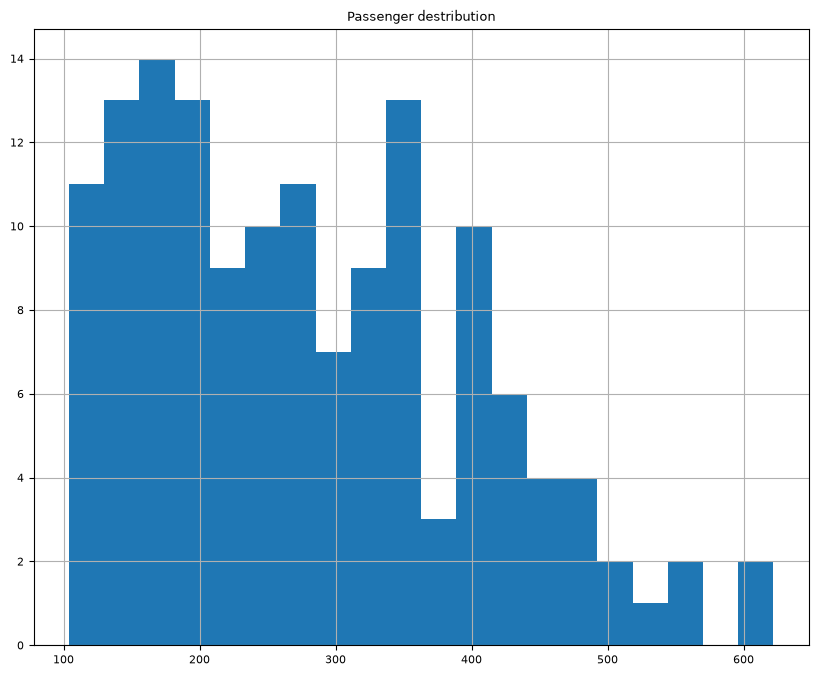

In [98]:
df1['Pax']. hist(bins=20)
plt.title ('Passenger destribution')

plt.show()

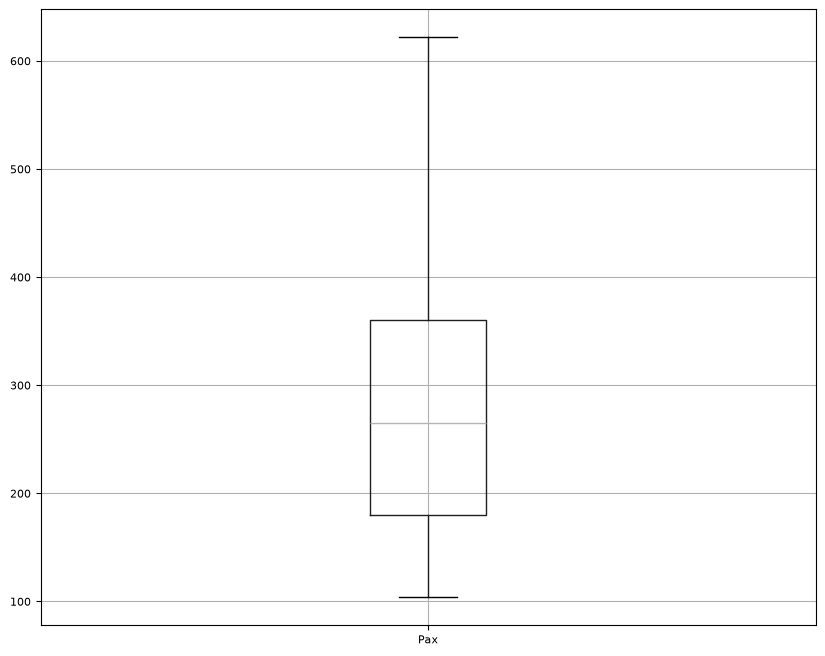

In [82]:

df1.boxplot(column ='Pax')
plt.show()

In [83]:
##decompose data to gain - Trend, Seasonality and errors

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose

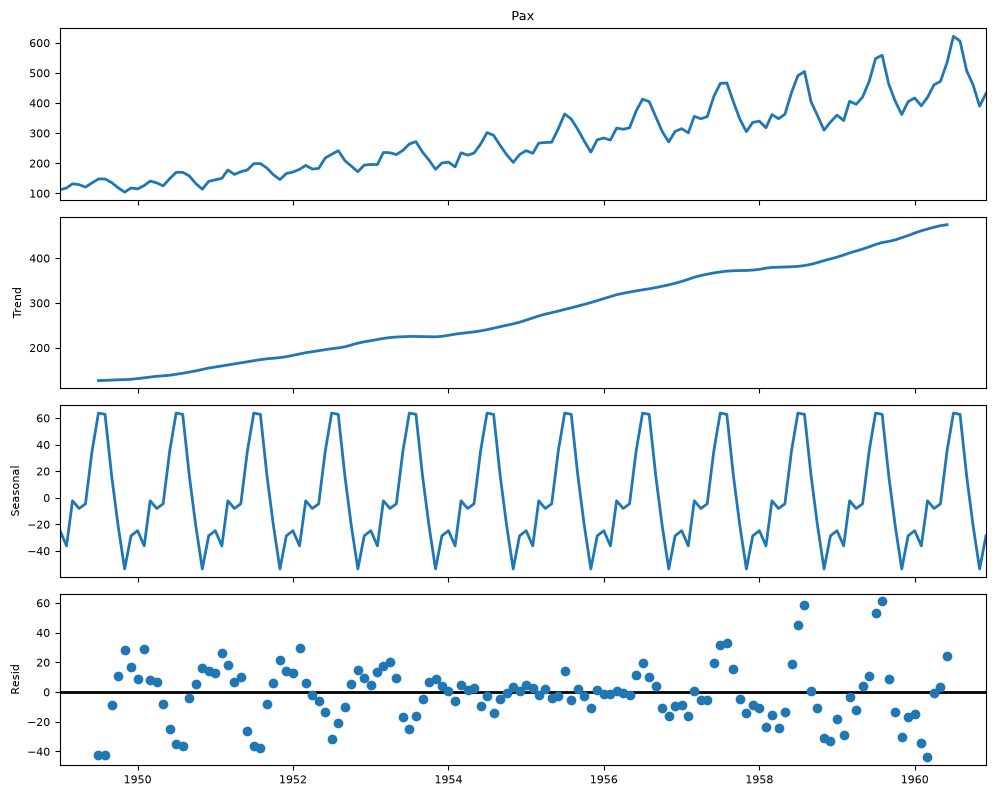

In [91]:
decom = seasonal_decompose(
                          df1['Pax'],
                            model = 'Multiplicative',
                            period = 12
                          )

decom.plot()
plt.show()    

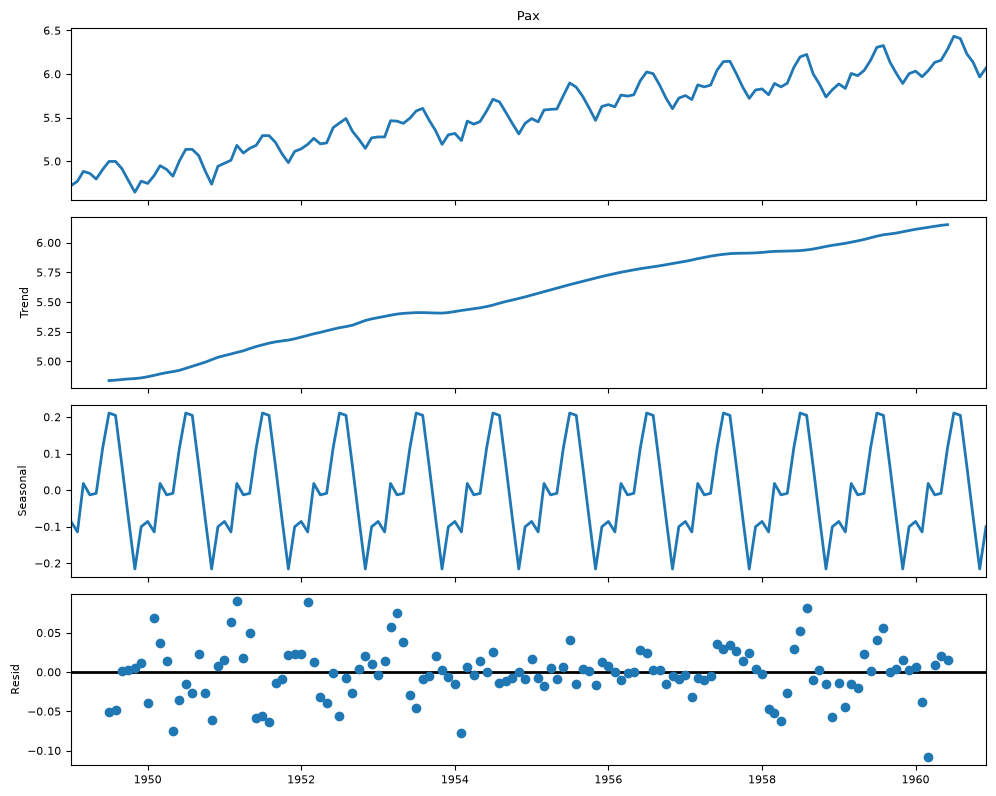

In [101]:
## Log transformation to fix the large residual values

df1_log = pd.DataFrame()

df1_log['Pax'] = np.log(df1['Pax'])


from statsmodels.tsa.seasonal import seasonal_decompose

df1_log = np.log(df1['Pax'])

result_log = seasonal_decompose(
    df1_log,
    model='additive',
    period=12
)

result_log.plot()
plt.show()




#Split the data into training and test. The test data should start from 1991.


In [94]:
print(df1.index.min())
print(df1.index.max())

1949-01-01 00:00:00
1960-12-01 00:00:00


In [96]:
train = df1[df1.index < '1956-12-01']
test = df1[df1.index >= '1956-12-01']

In [97]:
print("Trainig Data")
display(train)
print("Test Data")
display(test)

Trainig Data


,Pax
Year-Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1956-07-01,413
1956-08-01,405
1956-09-01,355


Test Data


,Pax
Year-Month,
1956-12-01,306
1957-01-01,315
1957-02-01,301
1957-03-01,356
1957-04-01,348
1957-05-01,355
1957-06-01,422
1957-07-01,465
1957-08-01,467


In [103]:
###Build various exponential smoothing models on the training data and evaluate the model using RMSE on the test data. Other models, 
#such as regression,naïve forecast models, simple average models etc. should also be built on the training data and check the performance on the 
#test data using RMSE.

In [133]:
train_reg = train.copy()
test_reg = test.copy()

train_reg['t'] = np.arange(len(train_reg))
test_reg['t'] = np.arange(
               len(train_reg),
               len(train_reg)+len(test_reg)
)
Ir = LinearRegression()
ir.fit(
    train_reg[['t']],
     train_reg['Pax']
)

forecast_reg = ir.predict(
              test_reg[['t']]

)

from sklearn.metrics import mean_squared_error

rmse_reg = np.sqrt(
    mean_squared_error(
        test_reg['Pax'],
        forecast_reg
    )
)


print("RMSE-" , rmse_reg )

    

RMSE- 71.50326413072636


In [134]:
##Let's creat output chart against this model

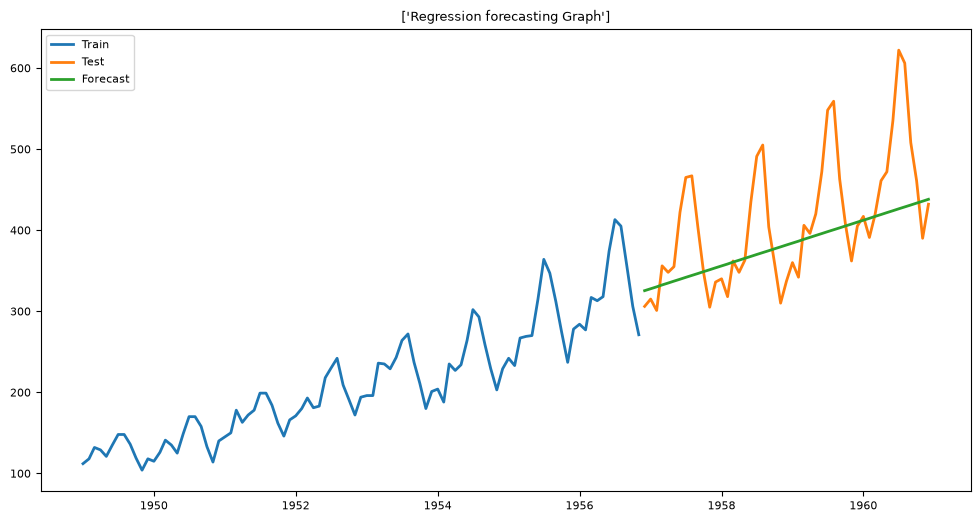

In [142]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Pax'])
plt.plot(test.index, test['Pax'])
plt.plot(test.index, forecast_reg)

plt.title(['Regression forecasting Graph'])
plt.legend(["Train", "Test", "Forecast"])
plt.show()

In [143]:
#Simple Average Model - 

In [148]:
forecast_avg = np.repeat(
                        train['Pax'].mean(),
                        len(test)
)

rmse_avg = rmse(
                test['Pax'],
                forecast_avg
    
                                )

print("RMSE:", rmse_avg)


RMSE: 213.45510819738584


In [149]:
##Let's plot this

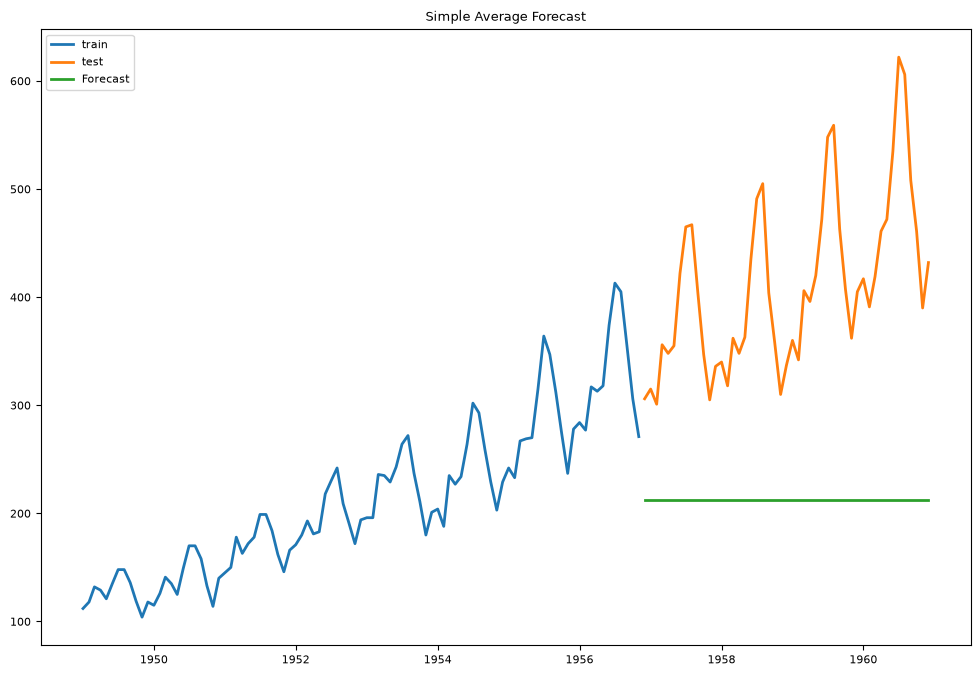

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,8))
plt.plot(train.index, train['Pax'])
plt.plot(test.index, test['Pax'])
plt.plot(test.index, forecast_avg)

plt.title("Simple Average Forecast")
plt.legend(["train", "test", "Forecast"])
plt.show()

In [158]:
##Moving Avg

In [171]:
window =12
moving_avg = train['Pax'].tail(window).mean()

Forecast_ma = np.repeat(
                 moving_avg,
                  len(test)
)

rmse_ma = rmse(
          test['Pax'],
          Forecast_ma
)

print("RMSE-", rmse_ma)
                  

RMSE- 115.88486899855299


In [163]:
#output chart

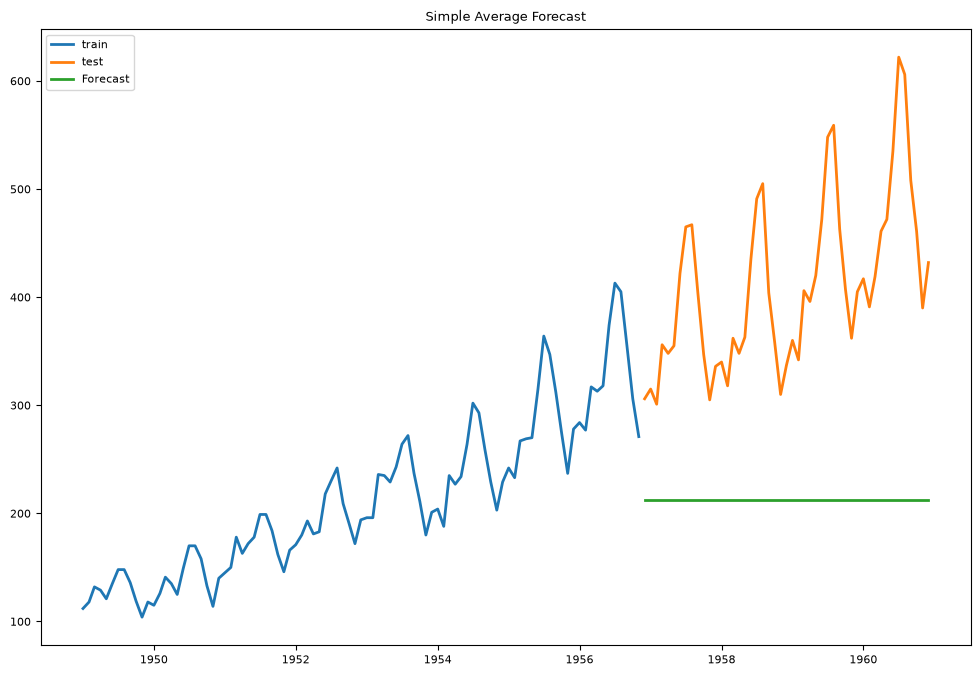

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,8))
plt.plot(train.index, train['Pax'])
plt.plot(test.index, test['Pax'])
plt.plot(test.index, forecast_avg)

plt.title("Moving Average Forecast")
plt.legend(["train", "test", "Forecast"])
plt.show()

In [ ]:
##Triple Exponential Smoothing (Holt-Winters)  - 

In [189]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
tes_model = ExponentialSmoothing(
            train['Pax'],
             trend = 'add',
            seasonal = 'mul',
            seasonal_periods = 12
).fit()


tes_forecast = tes_model.forecast(
                  len(test)

)

rmse_tse = rmse(
           test['Pax'],
           tes_forecast
)

print('RMSE-',rmse_tse )


C:\Users\parit\anaconda3_new\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RMSE- 29.676756347093118


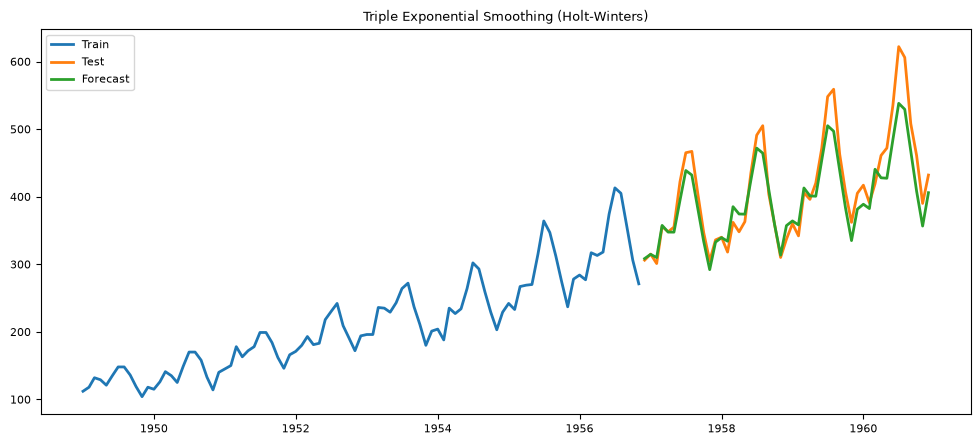

In [169]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Pax'])
plt.plot(test.index, test['Pax'])
plt.plot(test.index, tes_forecast)

plt.title('Triple Exponential Smoothing (Holt-Winters)')
plt.legend(['Train','Test','Forecast'])
plt.show()

In [170]:
##let's plot each RMSE value and check best model


In [187]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Simple avaerage',
        'Moving average',
        'Triple Expo. smoothing'
        ],
    'RMSE':[
        rmse_reg,
        rmse_avg,
        rmse_ma,
        rmse_tse
        ]


In [188]:
#sort the values

results = results.sort_values(by='RMSE')
print(results)

                    Model        RMSE
3  Triple Expo. smoothing   29.676756
0       Linear Regression   71.503264
2          Moving average  115.884869
1         Simple avaerage  213.455108


In [ ]:
##Hence, Triple Exponential Smoothing (Holt-Winters) is the best model to forecast the future sale.

#Thanks !
-
Sitesh Anand